# Classificação binária — câncer de mama (Wisconsin)

Demonstração de ponta a ponta da rede neural `Rede`, implementada do zero nesta biblioteca (sem frameworks de ML), aplicada à classificação de tumores como **benignos (0)** ou **malignos (1)**.

**Pipeline:** carregar os dados → dividir em treino/validação/teste → treinar → ajustar a taxa de aprendizado na validação → analisar a curva de aprendizado → avaliar no teste com métricas (acurácia, matriz de confusão, precisão, revocação e F1).

In [ ]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# coloca a raiz do repositorio no path, para importar a biblioteca da api
sys.path.insert(0, os.path.abspath('..'))
from api.main import Rede

## 1. Carregando os dados

O conjunto `bin_breast_cancer.csv` tem 569 amostras, 30 atributos numéricos e a coluna alvo `Diagnosis` (0 = benigno, 1 = maligno). As classes são levemente desbalanceadas (~63% benignos), o que torna a acurácia sozinha enganosa.

In [2]:
df = pd.read_csv('../datasets/clean/bin_breast_cancer.csv')
print('formato:', df.shape)
print('balanceamento das classes (Diagnosis):')
print(df['Diagnosis'].value_counts())
df.head()

formato: (569, 31)
balanceamento das classes (Diagnosis):
Diagnosis
0    357
1    212
Name: count, dtype: int64


,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,...,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst,Diagnosis
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,1
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,1
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,1
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,1
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1


## 2. Preparação dos dados

Os atributos já vêm padronizados (média 0, desvio 1), então não precisam de normalização extra. Dois cuidados importantes:

- A `Rede` espera **arrays numpy**, não um `DataFrame` do pandas (o laço de treino indexa as amostras por posição), por isso convertemos com `.to_numpy()`.
- Fazemos uma divisão **treino / validação / teste (60/20/20)**: o treino ajusta os pesos, a validação serve para escolher hiperparâmetros e o teste é usado uma única vez, na avaliação final.

In [3]:
# X = atributos (ja padronizados), y = rotulo (0=benigno, 1=maligno)
X = df.drop(columns=['Diagnosis']).to_numpy()
y = df[['Diagnosis']].to_numpy().astype(float)

# divisao treino/validacao/teste (60/20/20) com embaralhamento reprodutivel
rng = np.random.default_rng(42)
indices = rng.permutation(len(X))
n_train = int(0.60 * len(X))
n_val = int(0.20 * len(X))
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('treino:', X_train.shape, '| validacao:', X_val.shape, '| teste:', X_test.shape)

treino: (341, 30) | validacao: (113, 30) | teste: (115, 30)


## 3. Funções auxiliares: predição e métricas

A biblioteca ainda não tem um método `predict`, então envolvemos o `feedforward` (lembrando de acrescentar o slot do bias `1.0` a cada entrada). As métricas de classificação são implementadas **do zero com numpy**, já que `scikit-learn` é proibido pelo trabalho.

In [4]:
# probabilidade prevista (saida da sigmoide) para cada amostra
def predict_proba(rede, X_matrix):
    probabilities = []
    for i in range(len(X_matrix)):
        x = np.append(X_matrix[i], 1.0)  # acrescenta o slot do bias
        prediction, _ = rede.feedforward(x, np.zeros(1))  # y ficticio: so queremos a previsao
        probabilities.append(prediction[0])
    return np.array(probabilities)

# converte probabilidade em rotulo 0/1 por um limiar
def predict_label(rede, X_matrix, threshold=0.5):
    return (predict_proba(rede, X_matrix) >= threshold).astype(int)

# contagens da matriz de confusao (classe positiva = maligno = 1)
def confusion_counts(y_true, y_pred):
    y_true = y_true.ravel().astype(int)
    y_pred = y_pred.ravel().astype(int)
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    return tp, tn, fp, fn

# acuracia, precisao, revocacao e f1 a partir das contagens
def classification_metrics(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {'acuracia': accuracy, 'precisao': precision, 'revocacao': recall, 'f1': f1}

## 4. Treino e ajuste da taxa de aprendizado (validação)

Arquitetura: **30 atributos → 16 neurônios ReLU (camada oculta) → 1 neurônio sigmoide (saída = probabilidade)**, custo erro quadrático médio (MSE).

A inicialização dos pesos é **aleatória** — com `zeros` todos os neurônios de uma camada ficariam idênticos e a rede não aprenderia (problema de simetria). Treinamos com três taxas de aprendizado candidatas e escolhemos a melhor pela acurácia na **validação**.

In [5]:
# cria e configura a rede
def build_network(learning_rate):
    rede = Rede(learning_rate, atributes=X_train, labels=y_train)
    rede.weights_initialization_mode = 'random'  # 'zeros' nao aprende (simetria entre neuronios)
    rede.create_initial_layer(16, 'relu')        # camada oculta
    rede.create_hidden_layer(1, 'sigmoid')       # camada de saida (probabilidade)
    rede.set_cost_function('mean_squared_error')
    return rede

# ajuste da taxa de aprendizado usando o conjunto de validacao
candidate_learning_rates = [0.001, 0.01, 0.05]
results = []
for lr in candidate_learning_rates:
    np.random.seed(0)  # mesma inicializacao para uma comparacao justa
    candidate = build_network(lr)
    history = candidate.train(epochs=60)
    val_acc = classification_metrics(y_val, predict_label(candidate, X_val))['acuracia']
    results.append({'lr': lr, 'val_acc': val_acc, 'model': candidate, 'history': history})
    print(f'lr={lr:<6} acuracia na validacao = {val_acc:.4f}')

best = max(results, key=lambda r: r['val_acc'])
best_model = best['model']
best_history = best['history']
print()
print(f"melhor taxa de aprendizado: {best['lr']} (validacao = {best['val_acc']:.4f})")

lr=0.001  acuracia na validacao = 0.8761


lr=0.01   acuracia na validacao = 0.9646


lr=0.05   acuracia na validacao = 0.9735

melhor taxa de aprendizado: 0.05 (validacao = 0.9735)


## 5. Curva de aprendizado

A perda média por época do melhor modelo deve cair de forma consistente, evidenciando que o treino (feedforward → back_propagation → gradient_descent) está de fato reduzindo o erro.

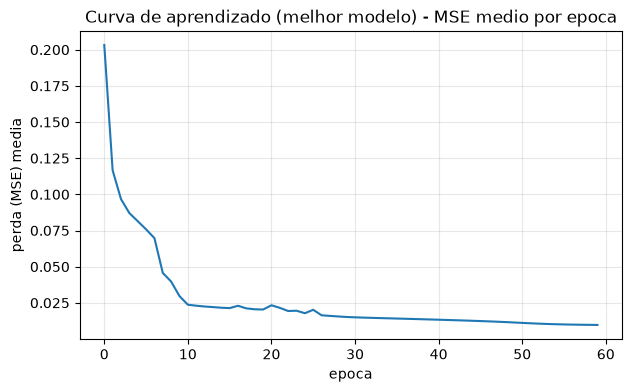

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(best_history)
plt.title('Curva de aprendizado (melhor modelo) - MSE medio por epoca')
plt.xlabel('epoca')
plt.ylabel('perda (MSE) media')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Avaliação final no conjunto de teste

Avaliamos o melhor modelo no conjunto de teste, que não foi usado em nenhuma decisão até aqui. Reportamos a matriz de confusão e as métricas: neste contexto médico, a **revocação** é a mais crítica, porque um falso negativo (tumor maligno classificado como benigno) é o erro mais grave.

In [7]:
test_pred = predict_label(best_model, X_test)
tp, tn, fp, fn = confusion_counts(y_test, test_pred)
m = classification_metrics(y_test, test_pred)

print('Conjunto de teste (classe positiva = maligno):')
print(f'  verdadeiros positivos (maligno detectado): {tp}')
print(f'  verdadeiros negativos (benigno correto):   {tn}')
print(f'  falsos positivos (benigno -> maligno):     {fp}')
print(f'  falsos negativos (maligno NAO detectado):  {fn}')
print()
print(f"acuracia:  {m['acuracia']:.4f}")
print(f"precisao:  {m['precisao']:.4f}")
print(f"revocacao: {m['revocacao']:.4f}")
print(f"f1:        {m['f1']:.4f}")

Conjunto de teste (classe positiva = maligno):
  verdadeiros positivos (maligno detectado): 41
  verdadeiros negativos (benigno correto):   71
  falsos positivos (benigno -> maligno):     2
  falsos negativos (maligno NAO detectado):  1

acuracia:  0.9739
precisao:  0.9535
revocacao: 0.9762
f1:        0.9647


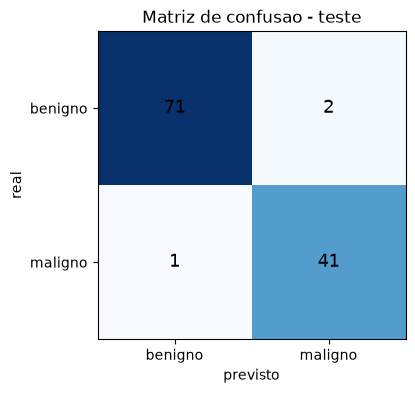

In [8]:
# matriz de confusao como mapa de calor
cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.matshow(cm, cmap='Blues')
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha='center', va='center', fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels(['benigno', 'maligno'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['benigno', 'maligno'])
ax.xaxis.set_ticks_position('bottom')
ax.set_xlabel('previsto'); ax.set_ylabel('real')
ax.set_title('Matriz de confusao - teste')
plt.show()

## 7. Conclusão

A rede neural aprendeu a distinguir tumores benignos de malignos com alta acurácia no conjunto de teste, como mostram as métricas acima.

Pontos importantes:

- **Revocação (recall)** é a métrica mais crítica aqui: um falso negativo significa deixar de detectar um tumor maligno — o erro mais perigoso no contexto médico. Por isso reportamos a matriz de confusão completa, e não apenas a acurácia (enganosa em dados desbalanceados, já que ~63% das amostras são benignas).
- O **conjunto de validação** guiou a escolha da taxa de aprendizado sem contaminar o conjunto de teste, usado uma única vez.
- A **inicialização aleatória** dos pesos foi essencial pois com 0 a rede não sairia do lugar.